In [ ]:
!pip -q install imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
filename= "/content/Loan_Data.csv"
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Filename:", filename)
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Filename: /content/Loan_Data.csv
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nTarget Distribution:")
display(df["Loan_Status"].value_counts())

print("\nTarget Distribution (%):")
display(df["Loan_Status"].value_counts(normalize=True) * 100)

Dataset Shape:
(614, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Pro

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14



Target Distribution:


,count
Loan_Status,
Y,422
N,192



Target Distribution (%):


,proportion
Loan_Status,
Y,68.729642
N,31.270358


In [ ]:
# Remove unnecessary ID column
df_model = df.copy()

if "Loan_ID" in df_model.columns:
    df_model = df_model.drop("Loan_ID", axis=1)

# Convert target Y/N to 1/0
df_model["Loan_Status"] = df_model["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

# Convert Dependents from 3+ to 3
if "Dependents" in df_model.columns:
    df_model["Dependents"] = df_model["Dependents"].replace("3+", "3")

print("Cleaned dataset:")
display(df_model.head())

Cleaned dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


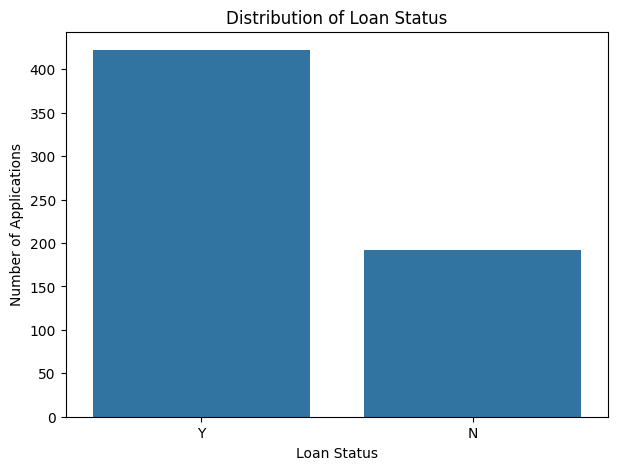

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Loan_Status"
)

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

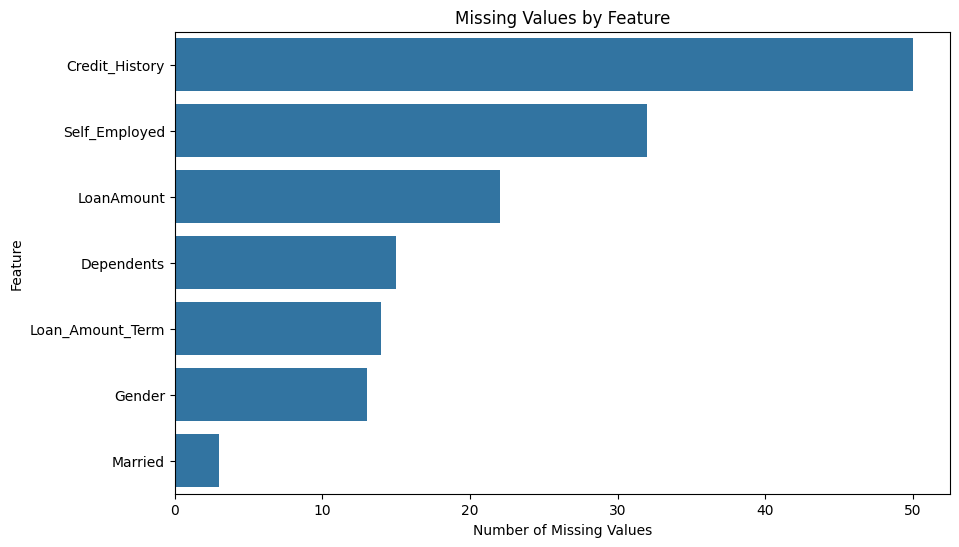

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

plt.show()

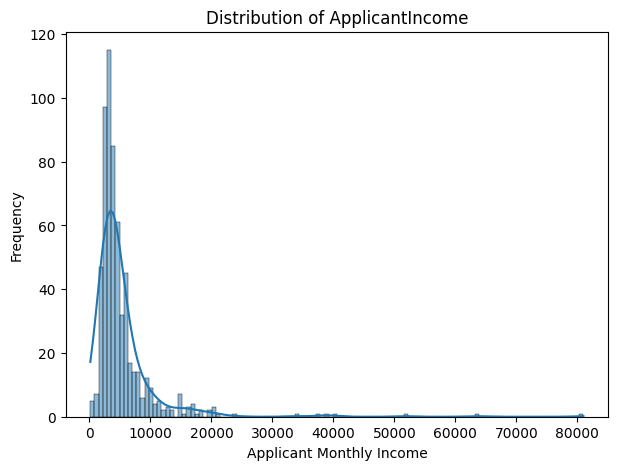

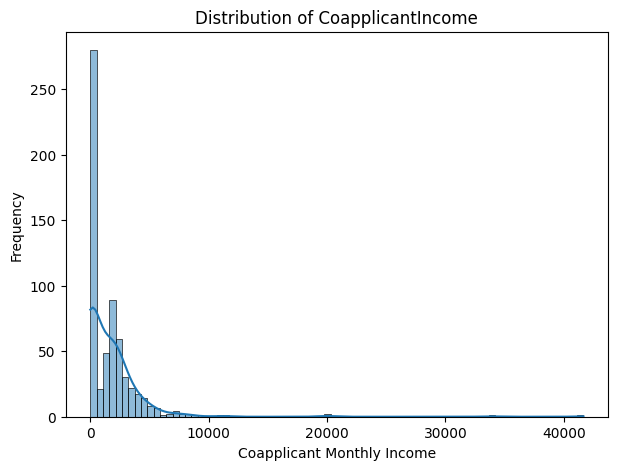

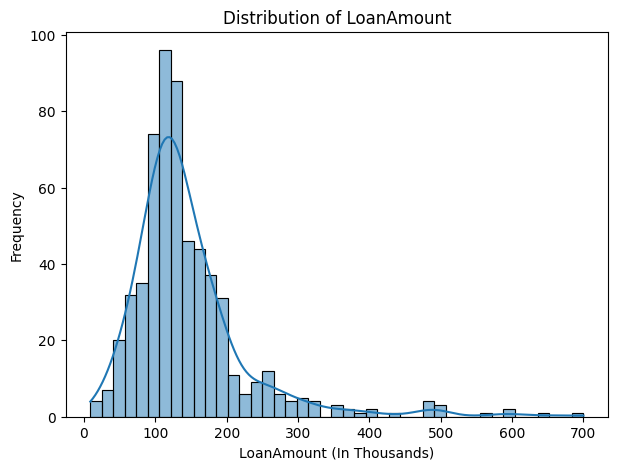

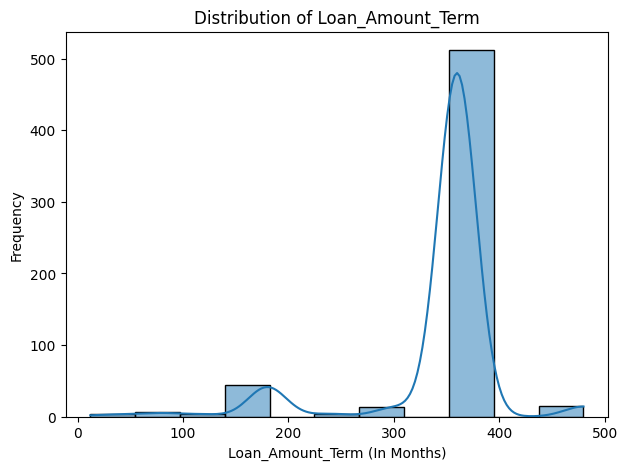

In [ ]:
numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

x_axis_labels = [
    "Applicant Monthly Income",
    "Coapplicant Monthly Income",
    "LoanAmount (In Thousands)",
    "Loan_Amount_Term (In Months)"
]

for column, x_label in zip(numeric_features, x_axis_labels):

    plt.figure(figsize=(7, 5))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(x_label)
    plt.ylabel("Frequency")

    plt.show()

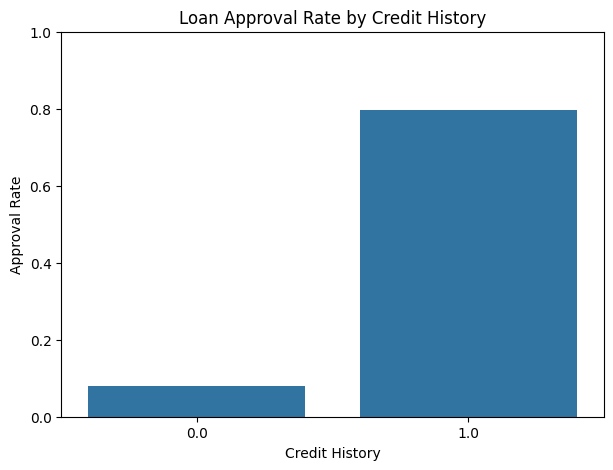

In [ ]:
credit_rate = (
    df.groupby("Credit_History")["Loan_Status"]
    .apply(lambda x: (x == "Y").mean())
    .reset_index()
)

credit_rate.columns = [
    "Credit_History",
    "Approval_Rate"
]

plt.figure(figsize=(7, 5))

sns.barplot(
    data=credit_rate,
    x="Credit_History",
    y="Approval_Rate"
)

plt.title("Loan Approval Rate by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Approval Rate")

plt.ylim(0, 1)

plt.show()

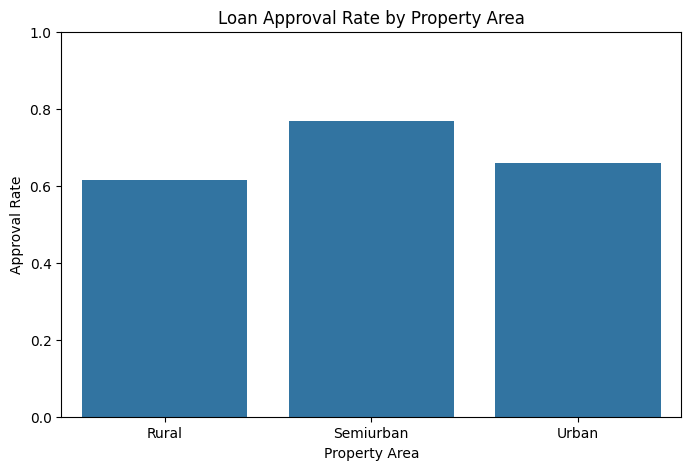

In [ ]:
property_rate = (
    df.groupby("Property_Area")["Loan_Status"]
    .apply(lambda x: (x == "Y").mean())
    .reset_index()
)

property_rate.columns = [
    "Property_Area",
    "Approval_Rate"
]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=property_rate,
    x="Property_Area",
    y="Approval_Rate"
)

plt.title("Loan Approval Rate by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Approval Rate")

plt.ylim(0, 1)

plt.show()

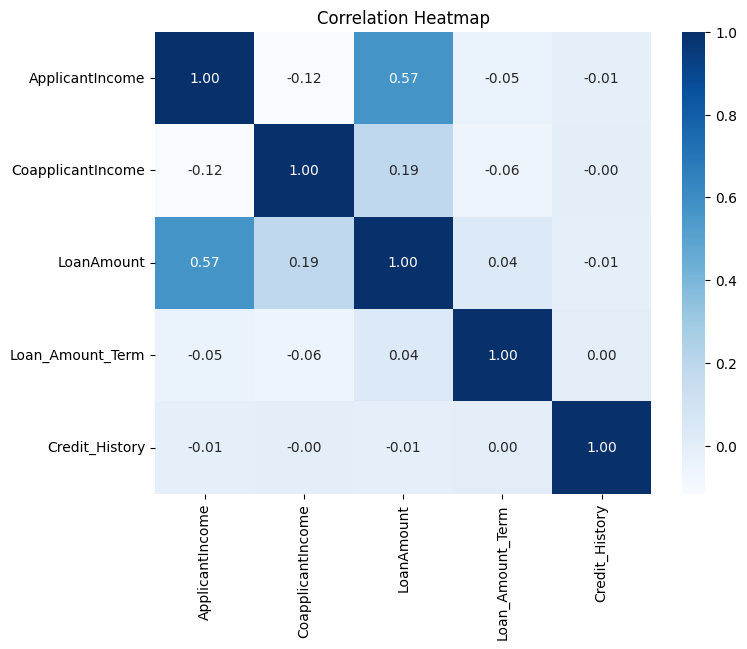

In [ ]:
corr_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

corr = df[corr_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


In [ ]:
data = df.copy()

# Drop ID
data = data.drop("Loan_ID", axis=1)

# Convert target
data["Loan_Status"] = data["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

# Convert Dependents
data["Dependents"] = data["Dependents"].replace("3+", "3")

# ------------------------------------------------------------
# Feature Engineering
# ------------------------------------------------------------

data["Total_Income"] = (
    data["ApplicantIncome"] +
    data["CoapplicantIncome"]
)

# Avoid division by zero
data["Loan_Income_Ratio"] = (
    data["LoanAmount"] /
    data["Total_Income"].replace(0, np.nan)
)

# Separate features and target
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (614, 13)
Target shape: (614,)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income,Loan_Income_Ratio
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,5849.0,NaN
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,6091.0,0.021015
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,3000.0,0.022000
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,4941.0,0.024287
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,6000.0,0.023500


In [ ]:
numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Total_Income",
    "Loan_Income_Ratio"
]

categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

# Credit History is treated separately as a numerical/binary feature
numeric_features_with_credit = numeric_features + [
    "Credit_History"
]

print("Numerical features:")
print(numeric_features_with_credit)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Loan_Income_Ratio', 'Credit_History']

Categorical features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 491
Testing samples: 123

Training class distribution:
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64

Testing class distribution:
Loan_Status
1    0.691057
0    0.308943
Name: proportion, dtype: float64


In [ ]:
# Numerical preprocessing WITH scaling
numeric_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Numerical preprocessing WITHOUT scaling
numeric_unscaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# ------------------------------------------------------------
# Scaled preprocessing
# ------------------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled, numeric_features_with_credit),
        ("cat", categorical_preprocessor, categorical_features)
    ]
)

# ------------------------------------------------------------
# Unscaled preprocessing
# ------------------------------------------------------------

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_unscaled, numeric_features_with_credit),
        ("cat", categorical_preprocessor, categorical_features)
    ]
)

print("Preprocessing pipelines created.")

Preprocessing pipelines created.


In [ ]:
models = {

    "SVM (RBF)": Pipeline([
        ("preprocessing", preprocessor_scaled),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    "Logistic Regression": Pipeline([
        ("preprocessing", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessing", preprocessor_unscaled),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessing", preprocessor_scaled),
        ("model", KNeighborsClassifier())
    ]),

    "Gradient Boosting (HistGB)": Pipeline([
        ("preprocessing", preprocessor_unscaled),
        ("model", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor_unscaled),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessing", preprocessor_scaled),
        ("model", GaussianNB())
    ])
}

print("Seven models created:")
for name in models:
    print("-", name)

Seven models created:
- SVM (RBF)
- Logistic Regression
- Random Forest
- KNN
- Gradient Boosting (HistGB)
- Decision Tree
- Naive Bayes


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():

    print(f"Running CV for: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Acc.": scores["test_accuracy"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "CV F1",
    ascending=False
)

display(cv_results_df)

Running CV for: SVM (RBF)
Running CV for: Logistic Regression
Running CV for: Random Forest
Running CV for: KNN
Running CV for: Gradient Boosting (HistGB)
Running CV for: Decision Tree
Running CV for: Naive Bayes


,Model,CV Acc.,CV F1,CV ROC-AUC
1,Logistic Regression,0.796248,0.868447,0.730824
0,SVM (RBF),0.792208,0.866118,0.745690
6,Naive Bayes,0.771820,0.848483,0.734066
2,Random Forest,0.771841,0.848080,0.787451
3,KNN,0.761616,0.841944,0.702899
4,Gradient Boosting (HistGB),0.761637,0.836830,0.740818
5,Decision Tree,0.710781,0.790713,0.659298


In [ ]:
final_results = []

for name, model in models.items():

    print(f"Training: {name}")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]

    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    test_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    test_f1 = f1_score(
        y_test,
        y_pred
    )

    test_roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Find CV results
    cv_row = cv_results_df[
        cv_results_df["Model"] == name
    ].iloc[0]

    final_results.append({

        "Model": name,

        "CV Acc.": cv_row["CV Acc."],

        "CV F1": cv_row["CV F1"],

        "CV ROC-AUC": cv_row["CV ROC-AUC"],

        "Test Acc.": test_accuracy,

        "Test F1": test_f1,

        "Test ROC-AUC": test_roc_auc
    })

results_df = pd.DataFrame(final_results)

results_df = results_df.sort_values(
    "CV F1",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "CV Acc.": "{:.3f}",
        "CV F1": "{:.3f}",
        "CV ROC-AUC": "{:.3f}",
        "Test Acc.": "{:.3f}",
        "Test F1": "{:.3f}",
        "Test ROC-AUC": "{:.3f}"
    })
)

Training: SVM (RBF)
Training: Logistic Regression
Training: Random Forest
Training: KNN
Training: Gradient Boosting (HistGB)
Training: Decision Tree
Training: Naive Bayes


,Model,CV Acc.,CV F1,CV ROC-AUC,Test Acc.,Test F1,Test ROC-AUC
0,Logistic Regression,0.796,0.868,0.731,0.862,0.908,0.875
1,SVM (RBF),0.792,0.866,0.746,0.854,0.903,0.872
2,Naive Bayes,0.772,0.848,0.734,0.846,0.896,0.837
3,Random Forest,0.772,0.848,0.787,0.854,0.897,0.854
4,KNN,0.762,0.842,0.703,0.894,0.926,0.887
5,Gradient Boosting (HistGB),0.762,0.837,0.741,0.837,0.884,0.825
6,Decision Tree,0.711,0.791,0.659,0.740,0.800,0.732


## Deep Learning: Neural Network Classifier

A feed-forward neural network (Multi-Layer Perceptron) is trained on the same scaled/encoded feature set used by the SVM, Logistic Regression, KNN, and Naive Bayes models (`preprocessor_scaled`). This lets us compare a deep learning approach against the classical ML baselines on identical folds/splits.

In [ ]:
# Deep Learning: Neural Network Classifier
!pip -q install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Reuse the existing scaled preprocessing pipeline (fit on training data only)
X_train_nn = preprocessor_scaled.fit_transform(X_train)
X_test_nn = preprocessor_scaled.transform(X_test)

y_train_nn = y_train.values.astype("float32")
y_test_nn = y_test.values.astype("float32")

n_features = X_train_nn.shape[1]
print("Number of input features after preprocessing:", n_features)

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

mlp_model = build_mlp(n_features)
mlp_model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("Training complete. Best epoch:", np.argmin(history.history["val_loss"]) + 1)


Number of input features after preprocessing: 22


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 128 (512.00 B)

Training complete. Best epoch: 10


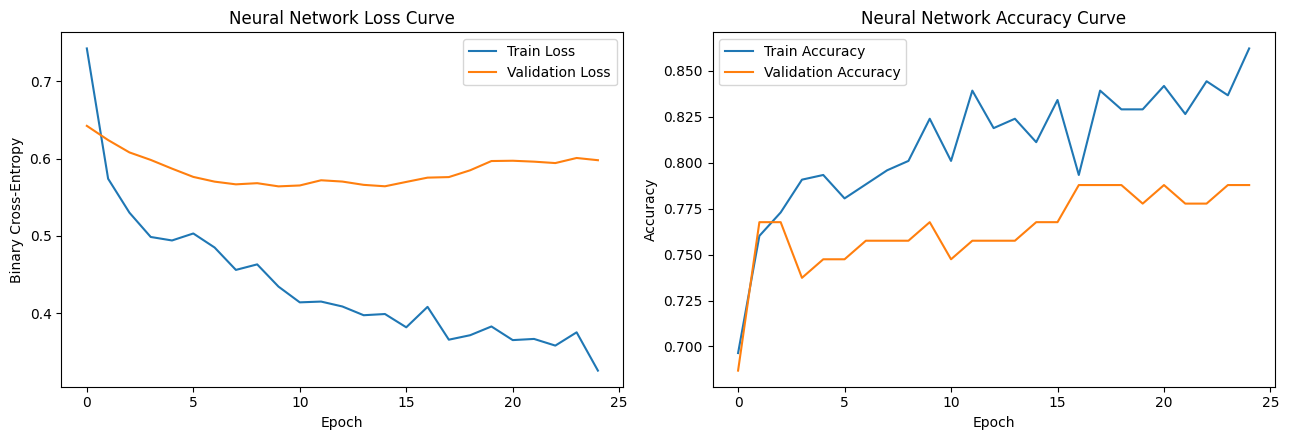

In [ ]:
# Training curves for the neural network
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Neural Network Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Neural Network Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


Neural Network Test Performance
Accuracy: 0.862
F1 Score: 0.906
ROC-AUC : 0.867

              precision    recall  f1-score   support

      Denied       0.89      0.63      0.74        38
    Approved       0.85      0.96      0.91        85

    accuracy                           0.86       123
   macro avg       0.87      0.80      0.82       123
weighted avg       0.86      0.86      0.85       123



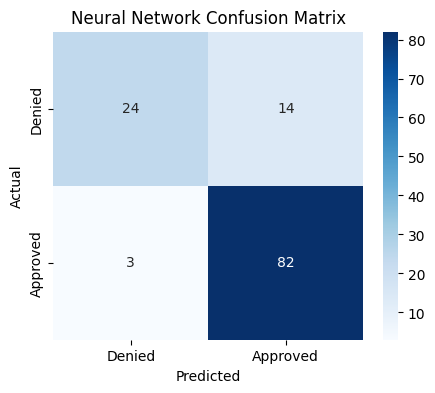

,Model,CV Acc.,CV F1,CV ROC-AUC,Test Acc.,Test F1,Test ROC-AUC
0,KNN,0.762,0.842,0.703,0.894,0.926,0.887
1,Logistic Regression,0.796,0.868,0.731,0.862,0.908,0.875
2,Neural Network (MLP),-,-,-,0.862,0.906,0.867
3,SVM (RBF),0.792,0.866,0.746,0.854,0.903,0.872
4,Random Forest,0.772,0.848,0.787,0.854,0.897,0.854
5,Naive Bayes,0.772,0.848,0.734,0.846,0.896,0.837
6,Gradient Boosting (HistGB),0.762,0.837,0.741,0.837,0.884,0.825
7,Decision Tree,0.711,0.791,0.659,0.740,0.800,0.732


In [ ]:
# Evaluate the neural network on the held-out test set
y_prob_nn = mlp_model.predict(X_test_nn, verbose=0).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test_nn, y_pred_nn)
nn_f1 = f1_score(y_test_nn, y_pred_nn)
nn_roc_auc = roc_auc_score(y_test_nn, y_prob_nn)

print("Neural Network Test Performance")
print("Accuracy:", round(nn_accuracy, 3))
print("F1 Score:", round(nn_f1, 3))
print("ROC-AUC :", round(nn_roc_auc, 3))
print()
print(classification_report(y_test_nn, y_pred_nn, target_names=["Denied", "Approved"]))

cm_nn = confusion_matrix(y_test_nn, y_pred_nn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Denied", "Approved"],
            yticklabels=["Denied", "Approved"])
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Add the neural network to the model comparison table built earlier
nn_row = {
    "Model": "Neural Network (MLP)",
    "CV Acc.": np.nan,
    "CV F1": np.nan,
    "CV ROC-AUC": np.nan,
    "Test Acc.": nn_accuracy,
    "Test F1": nn_f1,
    "Test ROC-AUC": nn_roc_auc
}

results_df_with_nn = pd.concat(
    [results_df, pd.DataFrame([nn_row])],
    ignore_index=True
).sort_values("Test F1", ascending=False).reset_index(drop=True)

display(
    results_df_with_nn.style.format({
        "CV Acc.": "{:.3f}",
        "CV F1": "{:.3f}",
        "CV ROC-AUC": "{:.3f}",
        "Test Acc.": "{:.3f}",
        "Test F1": "{:.3f}",
        "Test ROC-AUC": "{:.3f}"
    }, na_rep="-")
)


## Dimensionality Reduction: PCA

Principal Component Analysis (PCA) is applied to the scaled/encoded feature matrix to (1) visualize the loan applicants in 2D, (2) inspect how much variance is captured by each component, and (3) test whether a lower-dimensional representation retains enough signal for classification.

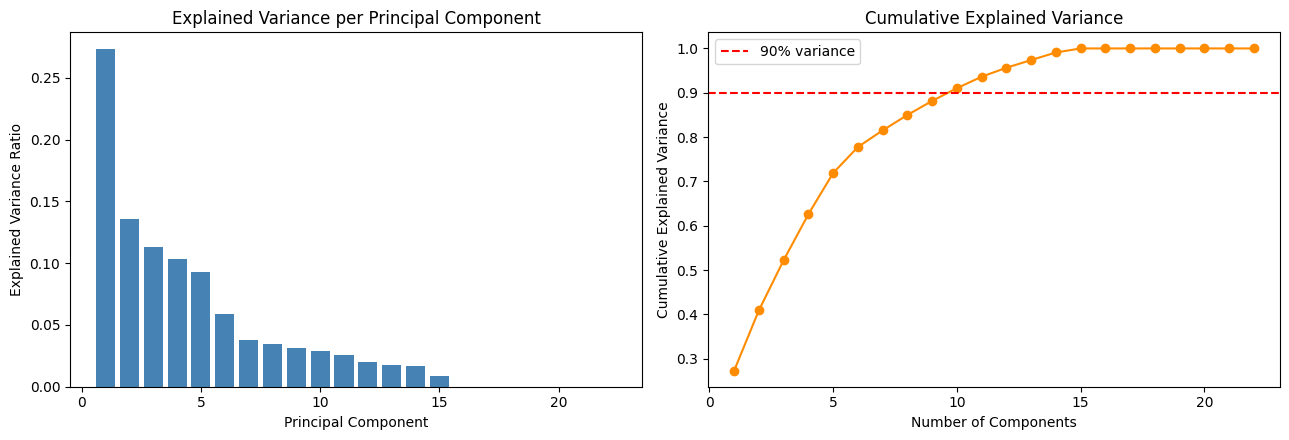

Number of components needed to explain 90% of variance: 10


In [ ]:
# Dimensionality Reduction: PCA
from sklearn.decomposition import PCA

# Use the same scaled/encoded features as the neural network
X_train_pca_input = X_train_nn
X_test_pca_input = X_test_nn

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_pca_input)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(explained_var) + 1), explained_var, color="steelblue")
axes[0].set_title("Explained Variance per Principal Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, marker="o", color="darkorange")
axes[1].axhline(0.90, color="red", linestyle="--", label="90% variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Number of components needed to explain 90% of variance: {n_components_90}")


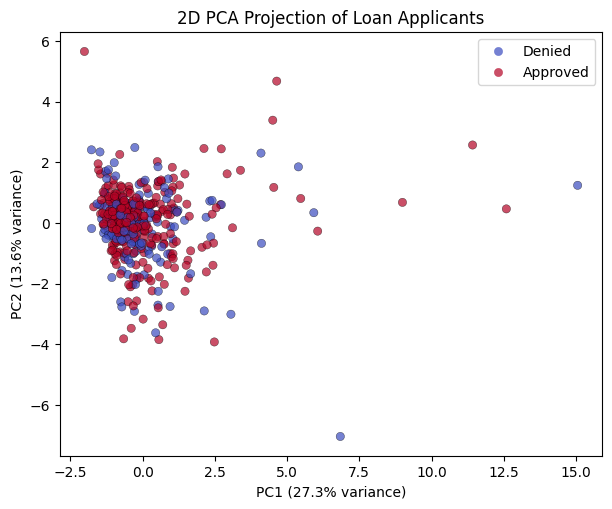

In [ ]:
# 2D PCA projection colored by loan approval status
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_pca_input)

plt.figure(figsize=(7, 5.5))
scatter = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train.values,
    cmap="coolwarm",
    alpha=0.7,
    edgecolor="k",
    linewidth=0.3
)
plt.title("2D PCA Projection of Loan Applicants")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(handles=scatter.legend_elements()[0], labels=["Denied", "Approved"])
plt.show()


In [ ]:
# Effect of PCA-based dimensionality reduction on downstream classification
pca_reduced = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_reduced = pca_reduced.fit_transform(X_train_pca_input)
X_test_reduced = pca_reduced.transform(X_test_pca_input)

print(f"Reduced feature space: {X_train_reduced.shape[1]} components "
      f"(from {X_train_pca_input.shape[1]} original scaled/encoded features)")

pca_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
pca_lr.fit(X_train_reduced, y_train)

y_pred_pca = pca_lr.predict(X_test_reduced)
y_prob_pca = pca_lr.predict_proba(X_test_reduced)[:, 1]

pca_accuracy = accuracy_score(y_test, y_pred_pca)
pca_f1 = f1_score(y_test, y_pred_pca)
pca_roc_auc = roc_auc_score(y_test, y_prob_pca)

print("\nLogistic Regression on PCA-Reduced Features")
print("Accuracy:", round(pca_accuracy, 3))
print("F1 Score:", round(pca_f1, 3))
print("ROC-AUC :", round(pca_roc_auc, 3))

print("\nFor comparison, Logistic Regression on the FULL feature set achieved:")
lr_full_row = results_df[results_df["Model"] == "Logistic Regression"].iloc[0]
print("Accuracy:", round(lr_full_row["Test Acc."], 3))
print("F1 Score:", round(lr_full_row["Test F1"], 3))
print("ROC-AUC :", round(lr_full_row["Test ROC-AUC"], 3))

pca_row = {
    "Model": f"Logistic Regression + PCA ({n_components_90} comps)",
    "CV Acc.": np.nan,
    "CV F1": np.nan,
    "CV ROC-AUC": np.nan,
    "Test Acc.": pca_accuracy,
    "Test F1": pca_f1,
    "Test ROC-AUC": pca_roc_auc
}

results_df_final = pd.concat(
    [results_df_with_nn, pd.DataFrame([pca_row])],
    ignore_index=True
).sort_values("Test F1", ascending=False).reset_index(drop=True)

display(
    results_df_final.style.format({
        "CV Acc.": "{:.3f}",
        "CV F1": "{:.3f}",
        "CV ROC-AUC": "{:.3f}",
        "Test Acc.": "{:.3f}",
        "Test F1": "{:.3f}",
        "Test ROC-AUC": "{:.3f}"
    }, na_rep="-")
)


Reduced feature space: 10 components (from 22 original scaled/encoded features)

Logistic Regression on PCA-Reduced Features
Accuracy: 0.862
F1 Score: 0.908
ROC-AUC : 0.884

For comparison, Logistic Regression on the FULL feature set achieved:
Accuracy: 0.862
F1 Score: 0.908
ROC-AUC : 0.875


,Model,CV Acc.,CV F1,CV ROC-AUC,Test Acc.,Test F1,Test ROC-AUC
0,KNN,0.762,0.842,0.703,0.894,0.926,0.887
1,Logistic Regression,0.796,0.868,0.731,0.862,0.908,0.875
2,Logistic Regression + PCA (10 comps),-,-,-,0.862,0.908,0.884
3,Neural Network (MLP),-,-,-,0.862,0.906,0.867
4,SVM (RBF),0.792,0.866,0.746,0.854,0.903,0.872
5,Random Forest,0.772,0.848,0.787,0.854,0.897,0.854
6,Naive Bayes,0.772,0.848,0.734,0.846,0.896,0.837
7,Gradient Boosting (HistGB),0.762,0.837,0.741,0.837,0.884,0.825
8,Decision Tree,0.711,0.791,0.659,0.740,0.800,0.732
